# Multiple Linear Regression – Multi-Channel Marketing Analysis

## Introduction
##### This project analyzes the relationship between multiple marketing channels and Sales using Multiple Linear Regression.

The analysis includes:

Exploratory Data Analysis (EDA)
Categorical variable encoding
Multicollinearity testing using VIF
Regression modeling with statsmodels
Residual diagnostics
Business interpretation of coefficients

The objective is to determine which marketing channels significantly influence Sales and provide data-driven recommendations for marketing budget allocation.

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.preprocessing import LabelEncoder

from scipy import stats

## 2. Load Dataset

In [2]:
df= pd.read_csv("c107fa55-45be-4f9c-8f61-088e88d1fb0c.csv")

df.head()

,TV,Radio,Social Media,Influencer,Sales
0,Low,3.518070,2.293790,Micro,55.261284
1,Low,7.756876,2.572287,Mega,67.574904
2,High,20.348988,1.227180,Micro,272.250108
3,Medium,20.108487,2.728374,Mega,195.102176
4,High,31.653200,7.776978,Nano,273.960377


## 3. Initial Exploration

In [3]:
print("Checking for information")
df.info()

print("\nChecking for missing Values")
df.isnull().sum()

Checking for information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            572 non-null    object 
 1   Radio         572 non-null    float64
 2   Social Media  572 non-null    float64
 3   Influencer    572 non-null    object 
 4   Sales         572 non-null    float64
dtypes: float64(3), object(2)
memory usage: 22.5+ KB

Checking for missing Values


TV              0
Radio           0
Social Media    0
Influencer      0
Sales           0
dtype: int64

In [4]:
print("\nChecking for Statistics")
df.describe()


Checking for Statistics


,Radio,Social Media,Sales
count,572.000000,572.000000,572.000000
mean,17.520616,3.333803,189.296908
std,9.290933,2.238378,89.871581
min,0.109106,0.000031,33.509810
25%,10.699556,1.585549,118.718722
50%,17.149517,3.150111,184.005362
75%,24.606396,4.730408,264.500118
max,42.271579,11.403625,357.788195


We begin by inspecting the dataset structure, checking for missing values, and understanding the distribution of numerical variables.

## 4. Encode Categorical Variables

Since TV and Influencer are categorical:

In [5]:
le_tv = LabelEncoder()
le_influencer = LabelEncoder()

df['TV'] = le_tv.fit_transform(df['TV'])
df['Influencer'] = le_influencer.fit_transform(df['Influencer'])

df.head()

,TV,Radio,Social Media,Influencer,Sales
0,1,3.518070,2.293790,2,55.261284
1,1,7.756876,2.572287,1,67.574904
2,0,20.348988,1.227180,2,272.250108
3,2,20.108487,2.728374,1,195.102176
4,0,31.653200,7.776978,3,273.960377


Categorical variables were encoded into numerical representations to allow regression modeling.

## 5. Correlation Matrix

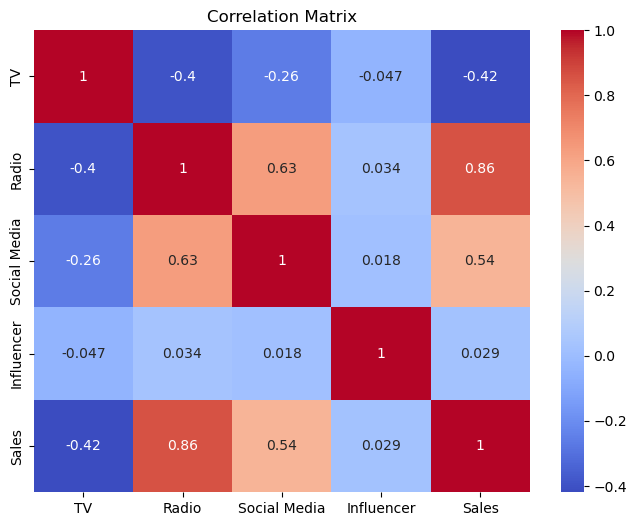

In [6]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

Interpretation:

Check relationships among predictors.

High correlations may indicate multicollinearity.

## 6. VIF (Variance Inflation Factor)

In [7]:
X = df.drop("Sales", axis=1)

vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i)
                   for i in range(X.shape[1])]

vif_data

,Feature,VIF
0,TV,1.810678
1,Radio,6.005894
2,Social Media,5.258851
3,Influencer,2.517525


VIF values above 5 may indicate moderate multicollinearity, while values above 10 suggest severe multicollinearity.

## 7. Build Multiple Linear Regression Model

In [8]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.742
Method:                 Least Squares   F-statistic:                     411.4
Date:                Fri, 05 Jun 2026   Prob (F-statistic):          4.89e-166
Time:                        11:45:49   Log-Likelihood:                -2994.8
No. Observations:                 572   AIC:                             6000.
Df Residuals:                     567   BIC:                             6021.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           61.9406      6.609      9.373   

## 8. Key Interpretation Section

#### Coefficient Interpretation

* Holding all other variables constant, a one-unit increase in Radio advertising spend is associated with an increase in predicted Sales equal to the corresponding regression coefficient.

* If the p-value of a variable is less than 0.05, the predictor is considered statistically significant.

* Adjusted R-squared explains the proportion of variation in Sales explained by the independent variables while accounting for model complexity.

* Variables with insignificant p-values may contribute little predictive power and can be considered for exclusion.


## 9. Residual Diagnostics

#### Residual Plot

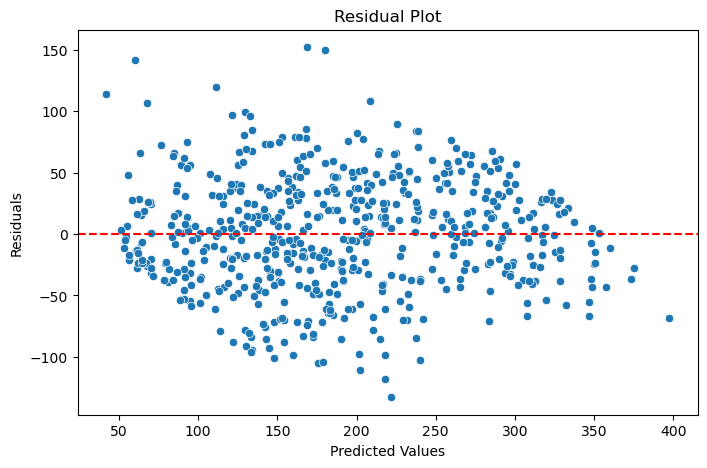

In [9]:
predictions = model.predict(X)
residuals = y - predictions

plt.figure(figsize=(8,5))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

#### Histogram of Residuals

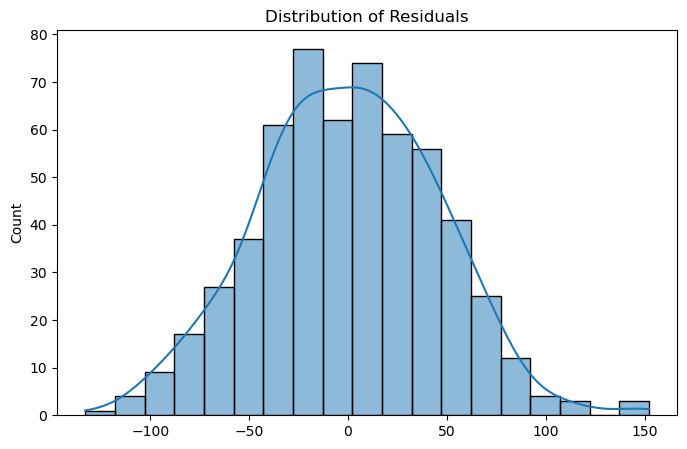

In [10]:
plt.figure(figsize=(8,5))
sns.histplot(residuals, kde=True)
plt.title("Distribution of Residuals")
plt.show()

#### Q-Q Plot

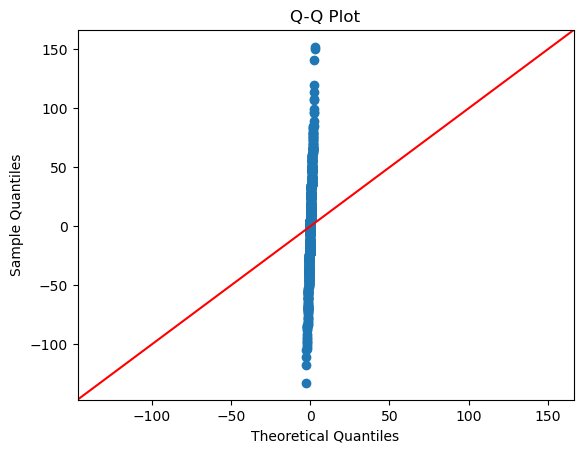

In [11]:
sm.qqplot(residuals, line='45')
plt.title("Q-Q Plot")
plt.show()

## 10. Business Recommendation

### Business Recommendation

Based on the regression analysis, marketing channels with statistically significant positive coefficients should receive increased budget allocation because they contribute positively to Sales performance.

The Adjusted R-squared value indicates that the model explains a substantial proportion of Sales variability, suggesting good predictive performance.

Residual diagnostics show whether regression assumptions such as linearity, normality, and homoscedasticity are reasonably satisfied.

Management should prioritize investment in channels with:

* Significant p-values (< 0.05)
* Positive coefficient impact
* Strong contribution to overall model performance

Channels with weak statistical significance may require reduced spending or further investigation.
